# Decomposing the trend signal

The 4-week trailing return on a coin is two things added together. The market's own 4-week return, shared by every coin, and the residual, how much the coin beat or lagged the market. The trend book bets the sign of the sum.

Split it. Bet each piece on its own and read what it earns. Ask whether the cross-section, the residual, trends or reverses, and at what horizon. Fit next-week return on the pieces plus funding, to see how much is market timing, how much is coin selection, and how much is carry. Then test the funding-aware sign, the trailing return net of the funding a position would have paid, against the plain sign.

## Setup

Load the panel and the shared book, then the market return and the 4-week own, market and residual returns.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from book import Book, halves, sharpe
import gate

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2})
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#8a8a86'

b = Book()
W, R, LIQ, VOL, F = b.W, b.R, b.LIQ, b.VOL, b.F
sized = b.sized

def book(sig):
    net = b.run(sized(sig.shift(1))).net
    tr = halves(net.index)
    return sharpe(net), sharpe(net[tr]), sharpe(net[~tr])

liquid = LIQ >= 1e7
market_ret = b.market_ret()
own4 = W.rolling(4, min_periods=4).sum()
mkt4 = market_ret.rolling(4, min_periods=4).sum()
resid4 = own4.sub(mkt4, axis=0)
print(f'panel {W.shape}  {W.index.min().date()} .. {W.index.max().date()}')

panel (349, 681)  2020-01-05 .. 2026-09-06


## The pieces

Four books at 4 weeks, same sizing. The plain trend, sign of the own return. The market trend, sign of the market return applied to every coin. The residual momentum, long the coins that beat the market and short those that lagged. And its reverse.

In [2]:
books = {'own trend, sign(own4)': np.sign(own4),
         'market trend, sign(mkt4)': (own4 * 0).add(np.sign(mkt4), axis=0),
         'residual momentum, sign(resid4)': np.sign(resid4),
         'residual reversal, -sign(resid4)': -np.sign(resid4)}
dec = pd.DataFrame({n: book(s) for n, s in books.items()}, index=['all', 'train', 'unseen']).T
print('net Sharpe'); print(dec.round(2))

net Sharpe
                                   all  train  unseen
own trend, sign(own4)             0.85   1.04    0.55
market trend, sign(mkt4)          0.80   0.87    0.67
residual momentum, sign(resid4)   0.28   0.23    0.39
residual reversal, -sign(resid4) -0.50  -0.42   -0.69


The trend book is the market book with a small kicker. Timing the market alone makes 0.80, the full per coin book 0.85, so coin selection adds 0.05. The selection that adds it is momentum, not reversal. Long the coins that beat the market makes 0.28, and its reverse loses 0.50. At 4 weeks the cross-section trends.

The later 40% of weeks, the unseen column, keeps the order, 0.67 for the market book and 0.55 per coin.

## Where the cross-section reverses

The residual book again, sign of the coin's return over the market, at formation horizons from 1 to 12 weeks.

In [3]:
hz = {}
for L in [1, 2, 3, 4, 6, 8, 12]:
    ownL = W.rolling(L, min_periods=L).sum()
    resid = ownL.sub(market_ret.rolling(L, min_periods=L).sum(), axis=0)
    hz[L] = dict(zip(['all', 'train', 'unseen'], book(np.sign(resid))))
hz = pd.DataFrame(hz).T; hz.index.name = 'L'
print('residual book net Sharpe by formation horizon'); print(hz.round(2))

residual book net Sharpe by formation horizon
     all  train  unseen
L                      
1  -0.49  -0.68   -0.07
2  -0.41  -0.49   -0.24
3  -0.22  -0.39    0.18
4   0.28   0.23    0.39
6   0.20  -0.11    0.76
8   0.14   0.01    0.36
12  0.07   0.05    0.10


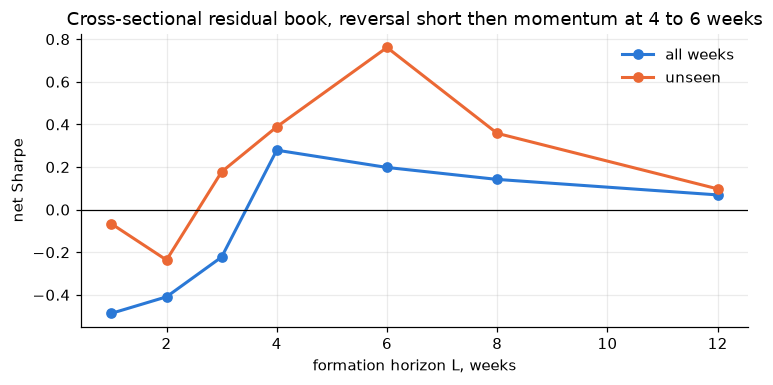

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(hz.index, hz['all'], marker='o', color=BLUE, label='all weeks')
ax.plot(hz.index, hz['unseen'], marker='o', color=ORANGE, label='unseen')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('formation horizon L, weeks'); ax.set_ylabel('net Sharpe')
ax.set_title('Cross-sectional residual book, reversal short then momentum at 4 to 6 weeks')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

The cross-section reverses at short horizons and trends at longer ones. Over 1 and 2 weeks, betting on the coins that just outperformed loses, 0.49 and 0.41. It crosses zero around 3 weeks, turns positive at 4 with 0.28, and fades to 0.07 by 12.

The later weeks peak at 6 with 0.76 while the earlier weeks lose there, so the peak does not hold across the sample. The 1 to 2 week reversal does, negative in both halves. It is a separate signal at a short horizon, not a piece of the 4-week trend, and belongs to the mean-reversion lane.

## Fitting the pieces to next-week return

Regress next-week return on the market, residual and funding terms, pooled across coins and weeks. Coefficients in basis points per standard deviation.

The market term is one number per week shared by every coin, so it is scaled by its spread across weeks. The residual and funding terms vary across coins, so they are scaled within each week. Coins in the same week move together, so the standard errors are clustered by week. A t-stat then counts weeks, not coin-weeks.

In [5]:
fund4 = F.rolling(4, min_periods=4).sum()
fwd = R.shift(-1)
elig = liquid & VOL.notna() & own4.notna() & resid4.notna() & fund4.notna() & fwd.notna()

def zc(df):
    v = df.where(elig)
    return v.sub(v.mean(axis=1), axis=0).div(v.std(axis=1), axis=0)

wk = mkt4.where(elig.any(axis=1))
market_z = (own4 * 0).add((wk - wk.mean()) / wk.std(), axis=0).where(elig)
terms = {'market 4wk': market_z, 'residual 4wk': zc(resid4), 'funding 4wk': zc(fund4)}
y = fwd.where(elig).values.ravel()
X = np.column_stack([np.ones(y.size)] + [t.values.ravel() for t in terms.values()])
week = np.repeat(np.arange(len(fwd)), fwd.shape[1])
ok = np.isfinite(X).all(1) & np.isfinite(y)
coef, se = gate.cluster_ols(y[ok], X[ok], week[ok])
ols = pd.DataFrame({'coef bps': coef * 1e4, 't': coef / se}, index=['const'] + list(terms)).round(2)
print(f'pooled OLS of next-week return, {ok.sum()} coin-weeks in {len(np.unique(week[ok]))} weeks, errors clustered by week')
print(ols)

pooled OLS of next-week return, 41354 coin-weeks in 335 weeks, errors clustered by week
              coef bps     t
const             7.75  0.11
market 4wk       93.24  1.33
residual 4wk     31.20  2.13
funding 4wk      32.76  3.00


Counted in weeks, the market term is weak. A one standard deviation stronger market trend adds 93 bps to next week at t 1.33, short of the usual bar of about 2. Coins in the same week move together, so the 41,354 coin-weeks carry little more evidence about the market than the 335 weeks they sit in. A regression that counts every coin-week as independent overstates the market term many times over.

The residual adds 31 bps at t 2.13, the weak cross-sectional momentum again. Funding adds 33 bps at t 3.00, the strongest of the three. Coins whose longs paid more over the last month rose slightly more the week after, before the funding a long pays for holding them. Funding carries information of its own, separate from both price terms.

## The funding-aware sign

A long in hot funding pays more than a small price move earns. Subtract the funding a long would have paid over the lookback from the trailing return before taking the sign, so a coin rising on paid carry reads weaker. If trend is partly carry paid to be long, the funding-aware sign keeps the price edge and sheds the carry drag. Coarse first, the same lookbacks as the sweep, per coin on \$10M coins.

In [6]:
fa = {}
for L in [1, 2, 4, 8, 12]:
    ret = W.rolling(L, min_periods=L).sum()
    fund = F.rolling(L, min_periods=L).sum()
    plain, aware = book(np.sign(ret)), book(np.sign(ret - fund))
    fa[L] = {'plain all': plain[0], 'aware all': aware[0], 'plain unseen': plain[2], 'aware unseen': aware[2]}
fa = pd.DataFrame(fa).T
fa.index.name = 'L'
print('net Sharpe, plain sign against funding-aware sign')
print(fa.round(2))

net Sharpe, plain sign against funding-aware sign
    plain all  aware all  plain unseen  aware unseen
L                                                   
1        0.57       0.63          0.26          0.30
2        0.43       0.38          0.25          0.23
4        0.85       0.81          0.55          0.56
8        0.55       0.58          0.24          0.19
12       0.44       0.49          0.12          0.18


The funding-aware sign is flat. It moves the net Sharpe by 0.06 or less at every lookback, up at 1, 8 and 12 weeks and down at 2 and 4, and the later weeks scatter the same way. Subtracting funding from the trailing return rarely flips the sign, and when it does the book neither gains nor loses. The plain sign is not harvesting carry paid to be long, and correcting for it adds nothing.

## Verdict

The 4-week trend is market timing plus a weak cross-sectional kicker. Timing the market is 0.80 of the book's 0.85, coin selection adds 0.05, and at this horizon selection is momentum, not reversal.

Counted in weeks, the market term is t 1.33. The timing earns in money but is thin as statistical evidence. The residual is t 2.13 and funding t 3.00, a separate term the funding-aware sign cannot turn into money. The cross-section reverses only at 1 to 2 weeks, a separate short-horizon signal.